In [42]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error
import matplotlib.pyplot as plt
import numpy as np

In [43]:
# Параметри
n = 3
shots = 1024

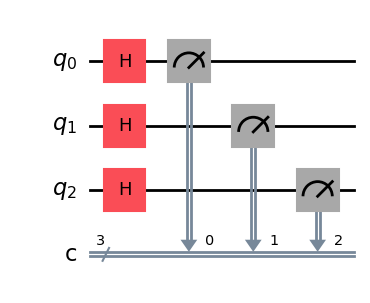

In [44]:
# Створення квантової схеми
qc = QuantumCircuit(n, n)

# Переведення кубітів у стан суперпозиції
qc.h(range(n))

# Вимірювання кубітів
qc.measure(range(n), range(n))
qc.draw('mpl')

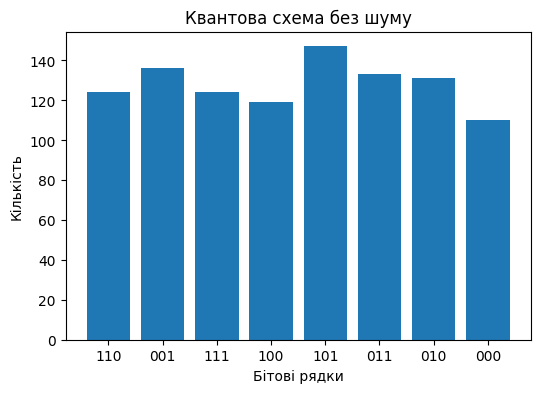

In [45]:
# Візуалізація квантової схеми без шуму
labels_clean = list(counts_clean.keys())
values_clean = list(counts_clean.values())

plt.figure(figsize=(6, 4))
plt.bar(labels_clean, values_clean)
plt.title("Квантова схема без шуму")
plt.xlabel("Бітові рядки")
plt.ylabel("Кількість")
plt.show()

Counts (без шуму): {'101': 113, '000': 146, '010': 125, '001': 119, '100': 141, '111': 128, '110': 126, '011': 126}


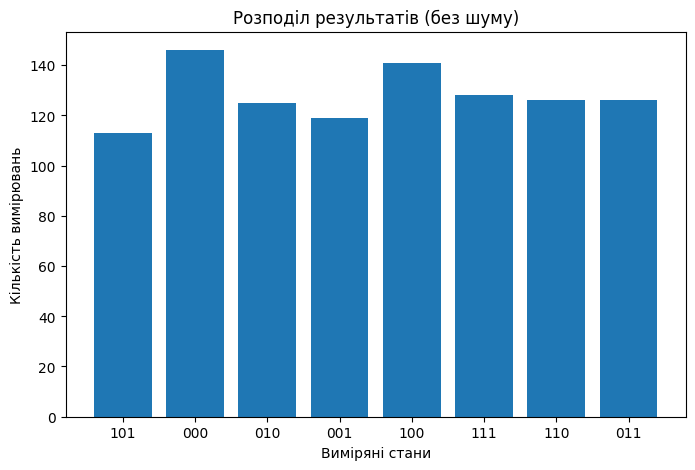

In [46]:
# Симуляція без шуму
backend = AerSimulator()
compiled = transpile(qc, backend)
job = backend.run(compiled, shots=shots)
result = job.result()
counts_clean = result.get_counts()

# Виведення результатів без шуму
print("Counts (без шуму):", counts_clean)

# Побудова гістограми результатів без шуму
states = list(counts_clean.keys())
values = list(counts_clean.values())

plt.figure(figsize=(8, 5))
plt.bar(states, values)
plt.xlabel("Виміряні стани")
plt.ylabel("Кількість вимірювань")
plt.title("Розподіл результатів (без шуму)")
plt.show()

In [47]:
# Підрахунок кількості нулів та одиниць
bit_string = ''.join(k * v for k, v in counts_clean.items())
zeros = bit_string.count('0')
ones = bit_string.count('1')

print(f"Кількість 0: {zeros}")
print(f"Кількість 1: {ones}")

Кількість 0: 1573
Кількість 1: 1499


In [48]:
# Створення моделі шуму
noise_model = NoiseModel()

# Додавання шуму типу bit-flip
bit_flip = pauli_error([('X', 0.05), ('I', 0.95)])

# Додавання depolarizing шуму
depolarizing = depolarizing_error(0.03, 1)

noise_model.add_all_qubit_quantum_error(bit_flip, ['measure'])
noise_model.add_all_qubit_quantum_error(depolarizing, ['h'])

Counts (з шумом): {'001': 135, '110': 123, '000': 112, '010': 135, '100': 128, '011': 141, '101': 124, '111': 126}


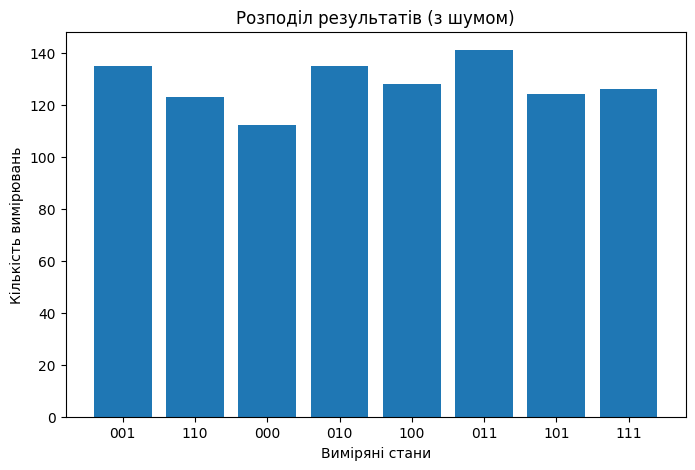

In [49]:
# Симуляція з шумом
backend_noise = AerSimulator(noise_model=noise_model)
compiled_noise = transpile(qc, backend_noise)
job_noise = backend_noise.run(compiled_noise, shots=shots)
result_noise = job_noise.result()
counts_noise = result_noise.get_counts()

# Виведення результатів з шумом
print("Counts (з шумом):", counts_noise)

# Побудова гістограми результатів з шумом
states_noise = list(counts_noise.keys())
values_noise = list(counts_noise.values())

plt.figure(figsize=(8, 5))
plt.bar(states_noise, values_noise)
plt.xlabel("Виміряні стани")
plt.ylabel("Кількість вимірювань")
plt.title("Розподіл результатів (з шумом)")
plt.show()

In [50]:
# Аналіз впливу шуму
bit_string_noise = ''.join(k * v for k, v in counts_noise.items())
zeros_noise = bit_string_noise.count('0')
ones_noise = bit_string_noise.count('1')

print(f"Кількість 0 (з шумом): {zeros_noise}")
print(f"Кількість 1 (з шумом): {ones_noise}")

Кількість 0 (з шумом): 1520
Кількість 1 (з шумом): 1552


In [51]:
# Реалізація коректора Фон Неймана
def von_neumann_extractor(bit_string):
    extracted = ""
    for i in range(0, len(bit_string) - 1, 2):
        pair = bit_string[i:i+2]
        if pair == "01":
            extracted += "0"
        elif pair == "10":
            extracted += "1"
    return extracted

# Застосування корекції
corrected_bits = von_neumann_extractor(bit_string_noise)

# Порівняння результатів до та після корекції
zeros_corr = corrected_bits.count('0')
ones_corr = corrected_bits.count('1')

print("Після корекції Фон Неймана:")
print(f"Кількість 0: {zeros_corr}")
print(f"Кількість 1: {ones_corr}")

Після корекції Фон Неймана:
Кількість 0: 392
Кількість 1: 392


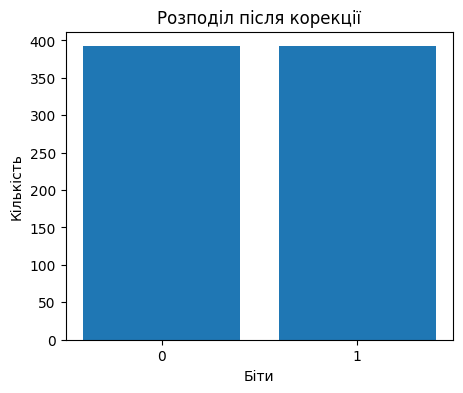

In [52]:
# Побудова гістограми після корекції
plt.figure(figsize=(5, 4))
plt.bar(['0', '1'], [zeros_corr, ones_corr])
plt.xlabel("Біти")
plt.ylabel("Кількість")
plt.title("Розподіл після корекції")
plt.show()